In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

# Load

In [12]:
periodo = 2

if periodo == 1:
    datasets = ['BDAP_periodo1', 'BDAP_anticipazioni_periodo1', 'anticipazioni_periodo1', 'BDAP_anticipazioni_new_periodo1']
    names = ['BDAP', 'BDAP + Anticipazioni', 'Anticipazioni', 'Ready BDAP + Anticipazioni']
else:
    datasets = ['BDAP_periodo2', 'BDAP_anticipazioni_periodo2', 'anticipazioni_periodo2', 'indicatori_periodo2','indicatori_anticipazioni_periodo2', 'BDAP_indicatori_anticipazioni_periodo2', 'BDAP_anticipazioni_new_periodo2']
    names = ['BDAP', 'BDAP + Anticipazioni', 'Anticipazioni', 'Indicatori', 'Indicatori + Anticipazioni', 'BDAP + Indicatori + Anticipazioni', 'Ready BDAP + Anticipazioni']

results = {}

for dataset in datasets:
    results[dataset] = {}
    # path = f'results/results_{dataset}.pickle'
    path = f'rss/results/results_{dataset}.pickle'
    temp = pickle.load(open(path, 'rb'))
    for pred, elem1 in temp.items():
        results[dataset][pred] = {}
        for lag, elem2 in elem1.items():
            results[dataset][pred][lag] = {}
            for model, elem3 in elem2.items():
                results[dataset][pred][lag][model] = elem3

In [13]:
points = []
labels = []
for name, result in results.items():
    name = names[datasets.index(name)]
    for pred, elem in result.items():
        for lag, elem2 in elem.items():
            for model, elem3 in elem2.items():
                points.append((elem3['roc_auc_test'], elem3['pr_auc_test'], elem3['precision_test'], elem3['recall_test']))
                labels.append((name, lag, pred, model))

roc = [elem[0] for elem in points]
pr = [elem[1] for elem in points]
precision = [elem[2] for elem in points]
recall = [elem[3] for elem in points]
f1 = [2 * (p * r) / (p + r) if (p + r) > 0 else 0 for p, r in zip(precision, recall)]

In [5]:
labels_t = []
pr_t = []
for elem1, elem2 in zip(labels, pr):
    if elem1[3] == 'Random Forest':
        labels_t.append(elem1)
        pr_t.append(elem2)

f1_t = []
for elem1, elem2 in zip(labels, f1):
    if elem1[3] == 'Random Forest':
        labels_t.append(elem1)
        f1_t.append(elem2)

In [6]:
t = labels_t[np.argmax(f1_t)]
t = labels[np.argmax(f1)]
name = datasets[names.index(t[0])]

In [7]:
t

('BDAP + Anticipazioni', 6, 3, 'Random Forest')

In [8]:
temp = results[name][t[2]][t[1]][t[3]]
print(f"{temp['precision_test']:.3f}", f"{temp['recall_test']:.3f}", f"{temp['f1_test']:.3f}")
# print(f"{np.mean(precision):.3f}", f"{np.mean(recall):.3f}", f"{np.mean(f1):.3f}")

0.344 0.272 0.303


In [9]:
temp

{'precision_test': 0.34375,
 'recall_test': 0.2716049382716049,
 'f1_test': 0.30344827586206896,
 'confusion_matrix_test': array([[2704,   42],
        [  59,   22]]),
 'roc_auc_test': 0.9079356729878701,
 'pr_auc_test': 0.24661447853029844,
 'best_threshold': 0.17,
 'best_f1': 1.0,
 'roc_curve_test': (array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.64166060e-04,
         7.28332119e-04, 7.28332119e-04, 2.54916242e-03, 2.54916242e-03,
         2.91332848e-03, 2.91332848e-03, 4.00582666e-03, 5.46249090e-03,
         5.82665696e-03, 5.82665696e-03, 6.91915513e-03, 8.37581937e-03,
         9.10415149e-03, 9.46831755e-03, 1.01966497e-02, 1.05608157e-02,
         1.12891479e-02, 1.16533139e-02, 1.20174800e-02, 1.31099782e-02,
         1.34741442e-02, 1.42024763e-02, 1.49308084e-02, 1.52949745e-02,
         1.52949745e-02, 1.63874727e-02, 1.71158048e-02, 1.78441369e-02,
         1.89366351e-02, 1.93008012e-02, 2.11216315e-02, 2.14857975e-02,
         2.22141296e-02, 2.25782957e-02, 

In [25]:
t = labels[np.argmax(roc)]
print(t)

('BDAP + Indicatori + Anticipazioni', 5, 3, 'Random Forest')


# Tables

In [14]:
name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

df = pd.DataFrame({
    'name': name,
    'pred': pred,
    'lag': lag,
    'model': model,
    'roc': roc,
    'pr': pr
})

# Summary functions
def summarize_metric(metric_series):
    return pd.Series({
        'min': metric_series.min(),
        'p5': np.percentile(metric_series, 5),
        'p25': np.percentile(metric_series, 25),
        'p50': np.percentile(metric_series, 50),
        'p75': np.percentile(metric_series, 75),
        'p95': np.percentile(metric_series, 95),
        'max': metric_series.max(),
        'mean': metric_series.mean(),
        'std': metric_series.std()
    })

grouping_keys = ['model', 'pred', 'lag', 'name']

summary_roc_dfs = {}
summary_pr_dfs = {}

for key in grouping_keys:
    roc_rows = []
    pr_rows = []
    grouped = df.groupby(key)

    for group_value, group_df in grouped:
        label = str(group_value)

        roc_stats = summarize_metric(group_df['roc'])
        pr_stats = summarize_metric(group_df['pr'])

        roc_stats[key] = label
        pr_stats[key] = label

        roc_rows.append(roc_stats)
        pr_rows.append(pr_stats)
    summary_roc = pd.DataFrame(roc_rows).set_index(key).sort_index()
    summary_pr = pd.DataFrame(pr_rows).set_index(key).sort_index()
    summary_roc = summary_roc.round(3)
    summary_pr = summary_pr.round(3)

    summary_roc_dfs[f"summary_roc_by_{key}"] = summary_roc
    summary_pr_dfs[f"summary_pr_by_{key}"] = summary_pr

    print(f"\n=== ROC Summary by {key.upper()} ===")
    print(summary_roc)
    
    print(f"\n=== PR Summary by {key.upper()} ===")
    print(summary_pr)




=== ROC Summary by MODEL ===
                       min     p5    p25    p50    p75    p95    max   mean  \
model                                                                         
CNN                  0.482  0.528  0.764  0.824  0.874  0.901  0.908  0.791   
Decision Tree        0.249  0.281  0.507  0.527  0.552  0.568  0.585  0.498   
GNN                  0.580  0.633  0.700  0.733  0.764  0.831  0.882  0.731   
Logistic Regression  0.697  0.748  0.799  0.863  0.889  0.928  0.934  0.851   
Random Forest        0.255  0.280  0.853  0.879  0.904  0.939  0.946  0.793   
XGBoost              0.339  0.597  0.792  0.835  0.872  0.897  0.912  0.808   

                       std  
model                       
CNN                  0.111  
Decision Tree        0.092  
GNN                  0.062  
Logistic Regression  0.059  
Random Forest        0.223  
XGBoost              0.108  

=== PR Summary by MODEL ===
                       min     p5    p25    p50    p75    p95    max   mean 

In [15]:
with open(f"tables_periodo{periodo}.tex", "w") as f:
    
    for key, df1 in summary_roc_dfs.items():
        df1 = df1.round(3)
        f.write(f"% Summary ROC for {key}\n")
        f.write(df1.to_latex(index=True, caption=f"ROC AUC Summary by {key}",float_format="%.3f".__mod__, label=f"tab:roc_{key}"))

    for key, df1 in summary_pr_dfs.items():
        df1 = df1.round(3)
        f.write(f"% Summary PR for {key}\n")
        f.write(df1.to_latex(index=True, caption=f"PR AUC Summary by {key}",float_format="%.3f".__mod__, label=f"tab:pr_{key}"))

In [16]:
# Median AUC tables: models as rows, datasets as columns
roc_median_pivot = pd.pivot_table(
    df, index='model', columns='name', values='roc', aggfunc='median',
).sort_index(axis=0).sort_index(axis=1)
pr_median_pivot = pd.pivot_table(
    df, index='model', columns='name', values='pr', aggfunc='median',
).sort_index(axis=0).sort_index(axis=1)

print("\n=== Median ROC AUC by Model x Dataset ===")
print(roc_median_pivot.round(3))

print("\n=== Median PR AUC by Model x Dataset ===")
print(pr_median_pivot.round(3))


=== Median ROC AUC by Model x Dataset ===
name                 Anticipazioni   BDAP  BDAP + Anticipazioni  \
model                                                             
CNN                          0.584  0.850                 0.808   
Decision Tree                0.287  0.550                 0.531   
GNN                          0.741  0.764                 0.717   
Logistic Regression          0.761  0.873                 0.870   
Random Forest                0.287  0.880                 0.859   
XGBoost                      0.625  0.870                 0.821   

name                 BDAP + Indicatori + Anticipazioni  Indicatori  \
model                                                                
CNN                                              0.838       0.868   
Decision Tree                                    0.545       0.522   
GNN                                              0.675       0.759   
Logistic Regression                              0.883       0.888   


In [17]:
# Save median AUC pivot tables to LaTeX (models x datasets)
roc_tex = roc_median_pivot.round(3).to_latex(
    index=True,
    caption=f"Median ROC AUC by Model x Dataset (period {periodo})",
    float_format="%.3f".__mod__,
    label="tab:median_roc_auc_model_dataset",
    escape=False
)
pr_tex = pr_median_pivot.round(3).to_latex(
    index=True,
    caption=f"Median PR AUC by Model x Dataset (period {periodo})",
    float_format="%.3f".__mod__,
    label="tab:median_pr_auc_model_dataset",
    escape=False
)

with open(f"tables_auc_periodo{periodo}.tex", "w") as f:
    f.write("% Median ROC AUC pivot table (models x datasets)\n")
    f.write(roc_tex)
    f.write("\n% Median PR AUC pivot table (models x datasets)\n")
    f.write(pr_tex)
print(f"Saved LaTeX tables to tables_auc_periodo{periodo}.tex")

Saved LaTeX tables to tables_auc_periodo2.tex


# Ellipse

In [18]:
from matplotlib.patches import Ellipse
import numpy as np

def plot_confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    if len(x) < 2:
        return  # Can't draw ellipse
    cov = np.cov(x, y)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    if cov.shape == (2, 2):
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * n_std * np.sqrt(vals)
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=theta, **kwargs)
        ax.add_patch(ellipse)



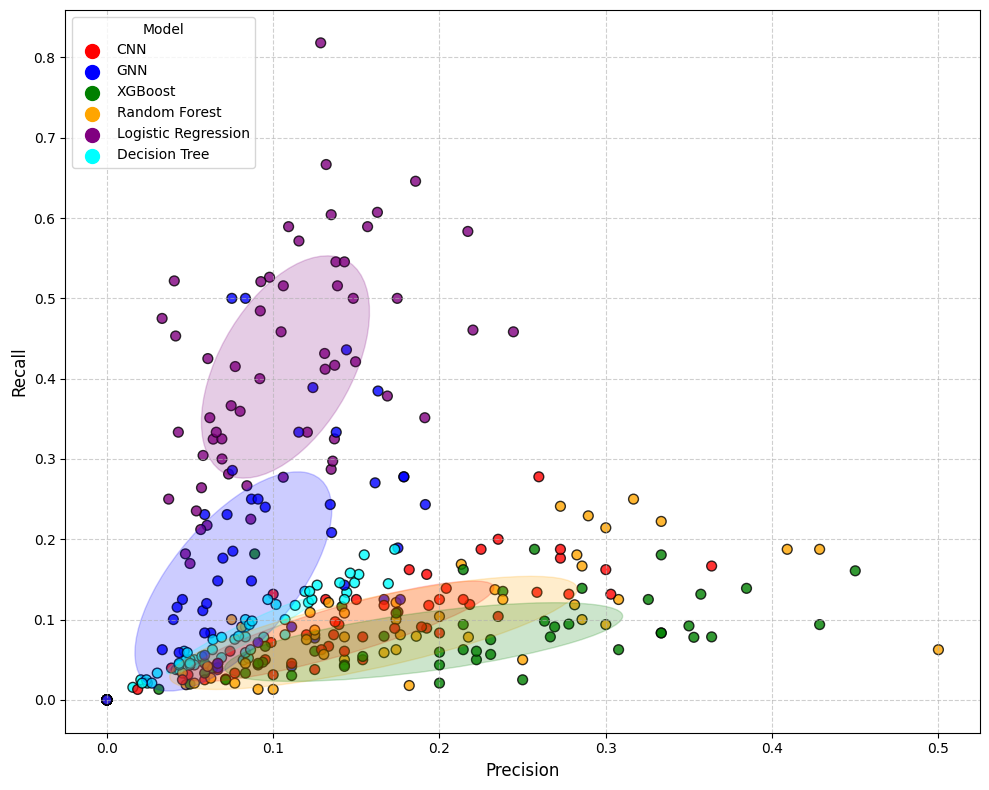

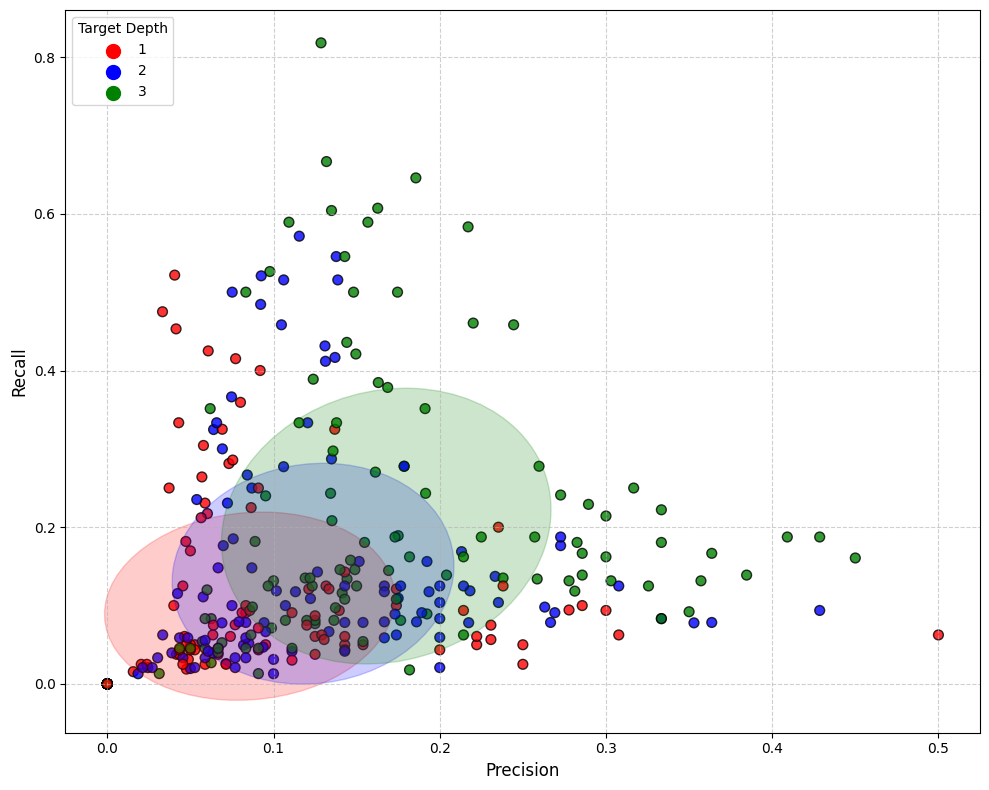

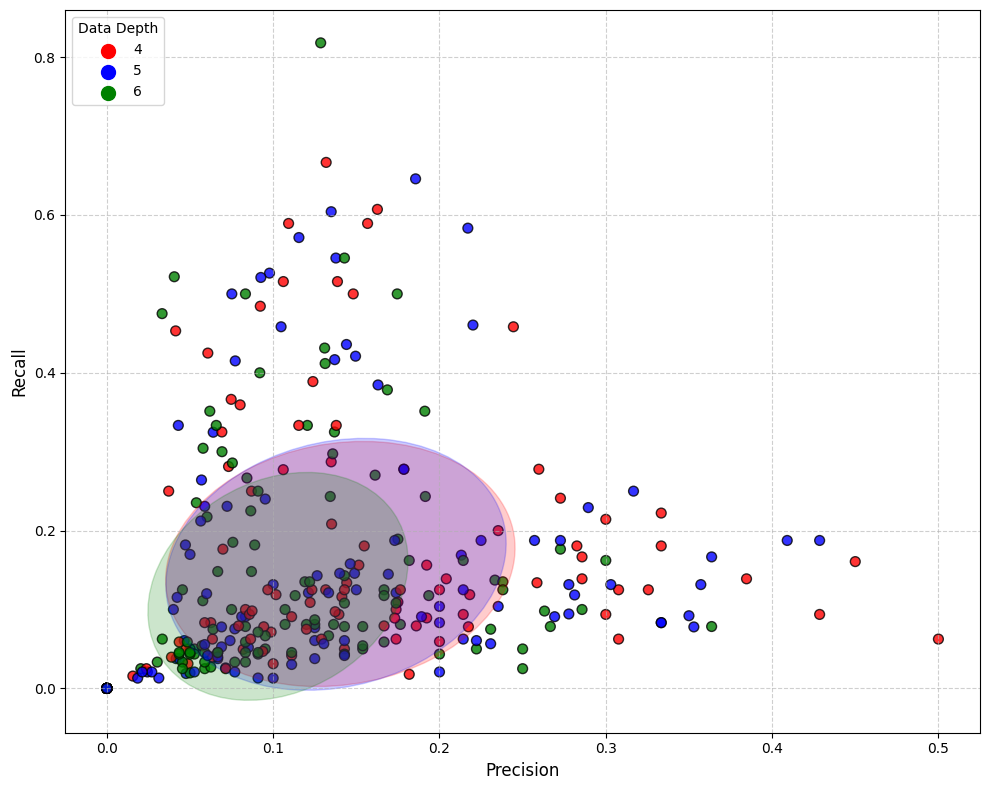

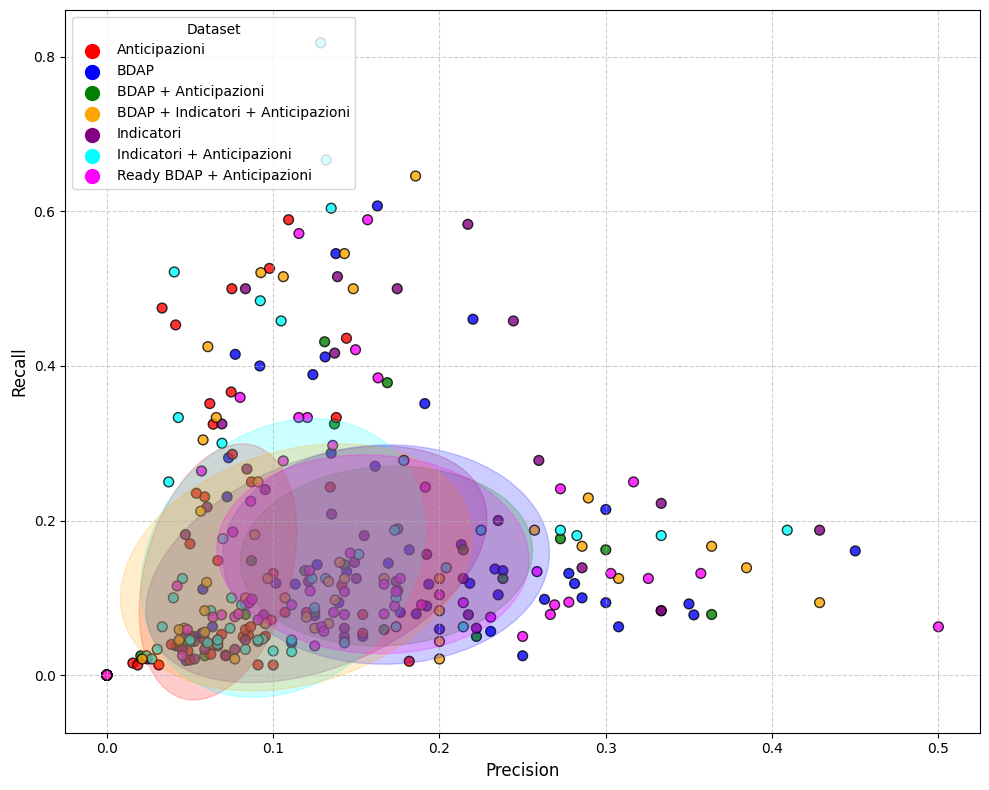

In [19]:
save = 1

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['Model', 'Target Depth', 'Data Depth', 'Dataset']):

    if color_by == "model":
        unique_values = ['CNN', 'GNN', 'XGBoost', 'Random Forest', 'Logistic Regression', 'Decision Tree']
    elif color_by == "pred":
        unique_values = sorted(list(set(pred)))
    elif color_by == "lag":
        unique_values = sorted(list(set(lag)))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(precision, recall, c=label_colors, s=50, edgecolor='k', alpha=0.8)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='upper left')

    grouped_points = {}

    for i in range(len(precision)):
        key = None
        if color_by == "model":
            key = model[i]
        elif color_by == "pred":
            key = pred[i]
        elif color_by == "lag":
            key = lag[i]
        elif color_by == "name":
            key = name[i]

        if key not in grouped_points:
            grouped_points[key] = []
        grouped_points[key].append((precision[i], recall[i]))
    
    ax = plt.gca()
    for key, points in grouped_points.items():
        if len(points) >= 2:
            points_array = np.array(points)
            plot_confidence_ellipse(points_array[:, 0], points_array[:, 1], ax, n_std=1.0, edgecolor=cmap[key], facecolor=cmap[key], alpha=0.2)


    plt.xlabel("Precision", fontsize=12) 
    plt.ylabel("Recall", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_precision_recall_periodo{periodo}.png')
    plt.show()


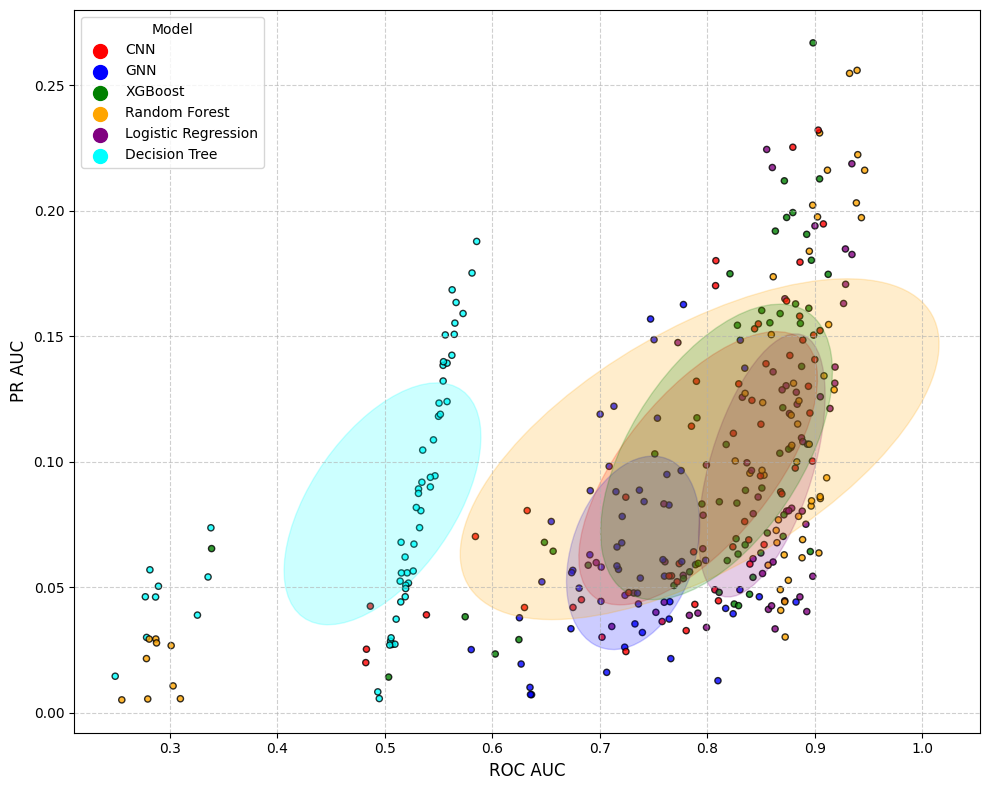

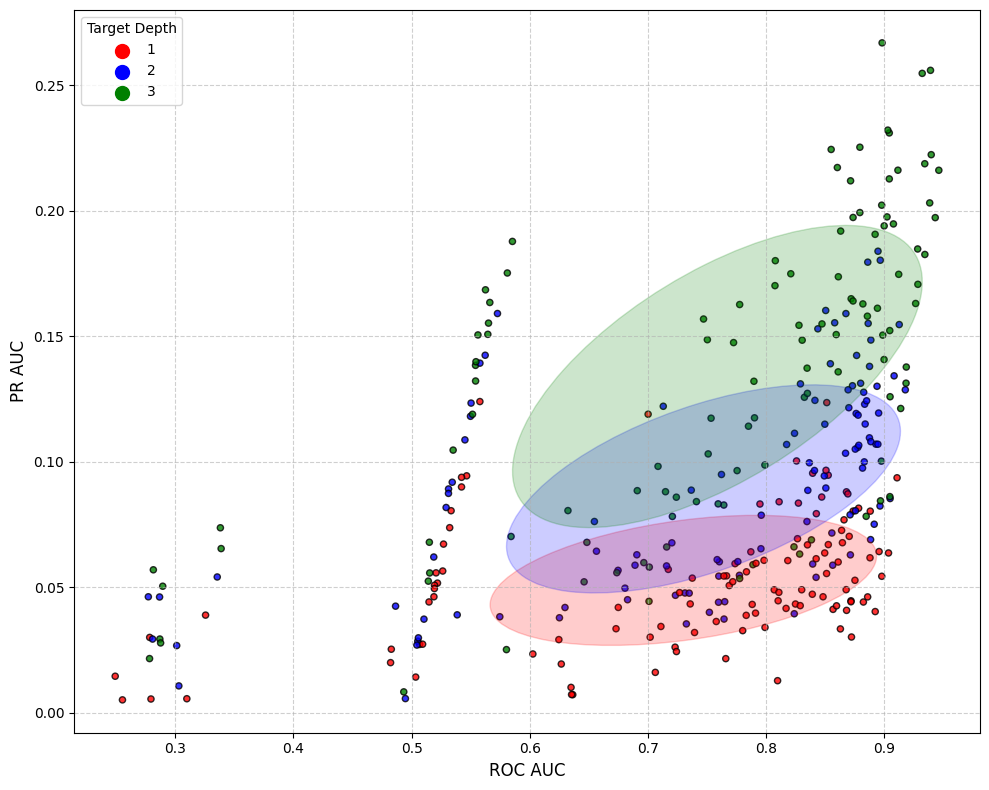

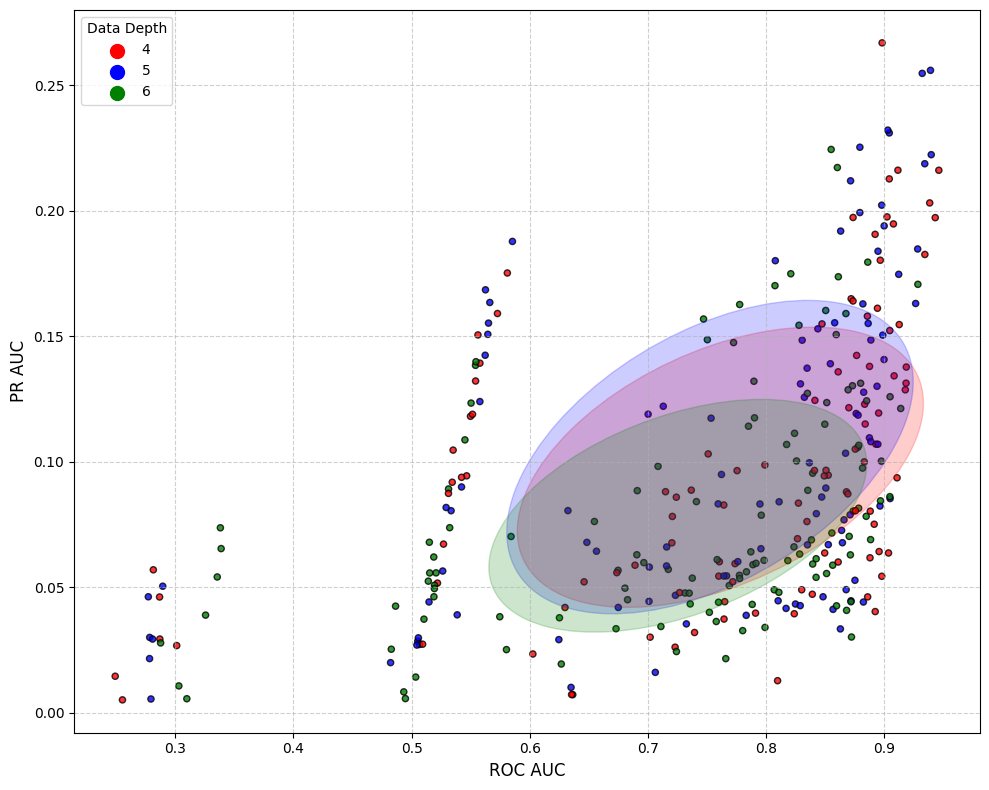

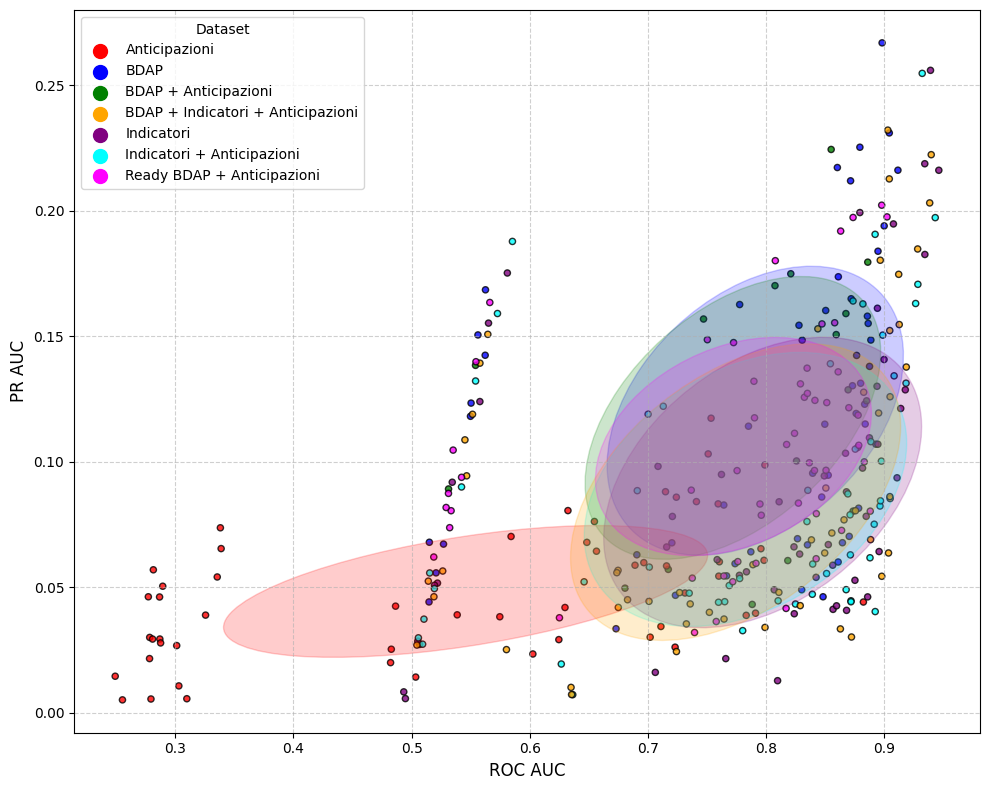

In [20]:
save = 1

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['Model', 'Target Depth', 'Data Depth', 'Dataset']):

    if color_by == "model":
        unique_values = ['CNN', 'GNN', 'XGBoost', 'Random Forest', 'Logistic Regression', 'Decision Tree']
    elif color_by == "pred":
        unique_values = sorted(list(set(pred)))
    elif color_by == "lag":
        unique_values = sorted(list(set(lag)))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(roc, pr, c=label_colors, s=20, edgecolor='k', alpha=0.8)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='upper left')

    grouped_points = {}

    for i in range(len(roc)):
        key = None
        if color_by == "model":
            key = model[i]
        elif color_by == "pred":
            key = pred[i]
        elif color_by == "lag":
            key = lag[i]
        elif color_by == "name":
            key = name[i]

        if key not in grouped_points:
            grouped_points[key] = []
        grouped_points[key].append((roc[i], pr[i]))
    
    ax = plt.gca()
    for key, points in grouped_points.items():
        if len(points) >= 2:
            points_array = np.array(points)
            plot_confidence_ellipse(points_array[:, 0], points_array[:, 1], ax, n_std=1.0, edgecolor=cmap[key], facecolor=cmap[key], alpha=0.2)


    plt.xlabel("ROC AUC", fontsize=12) 
    plt.ylabel("PR AUC", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_auc_periodo{periodo}.png')
    plt.show()

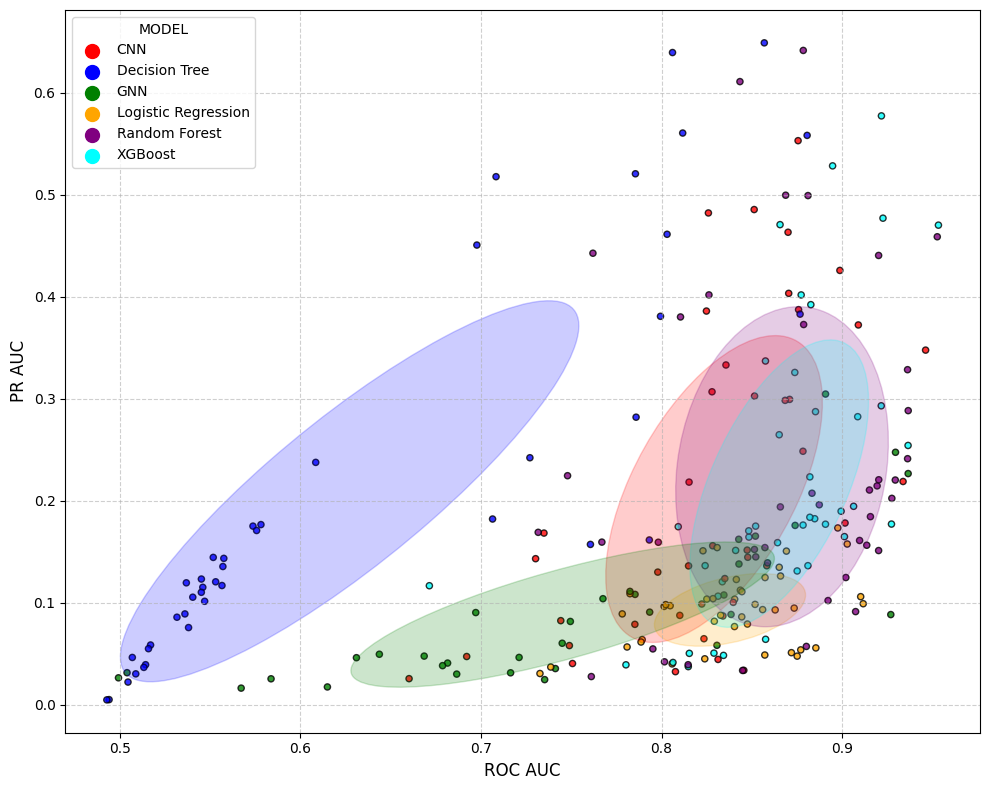

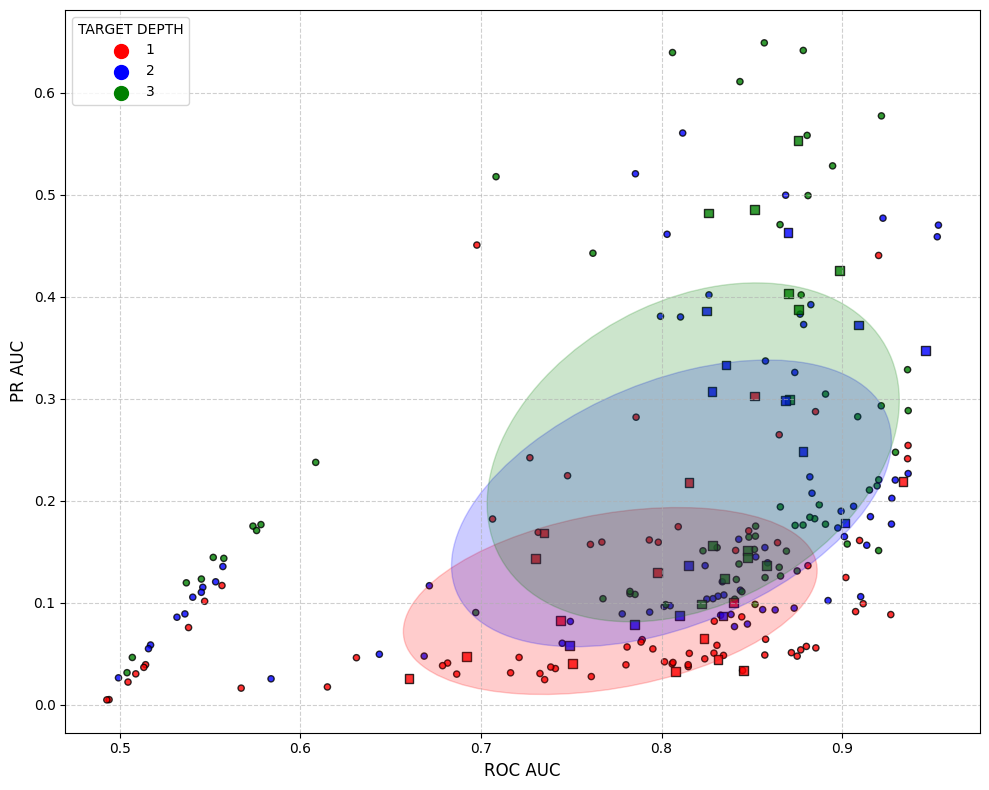

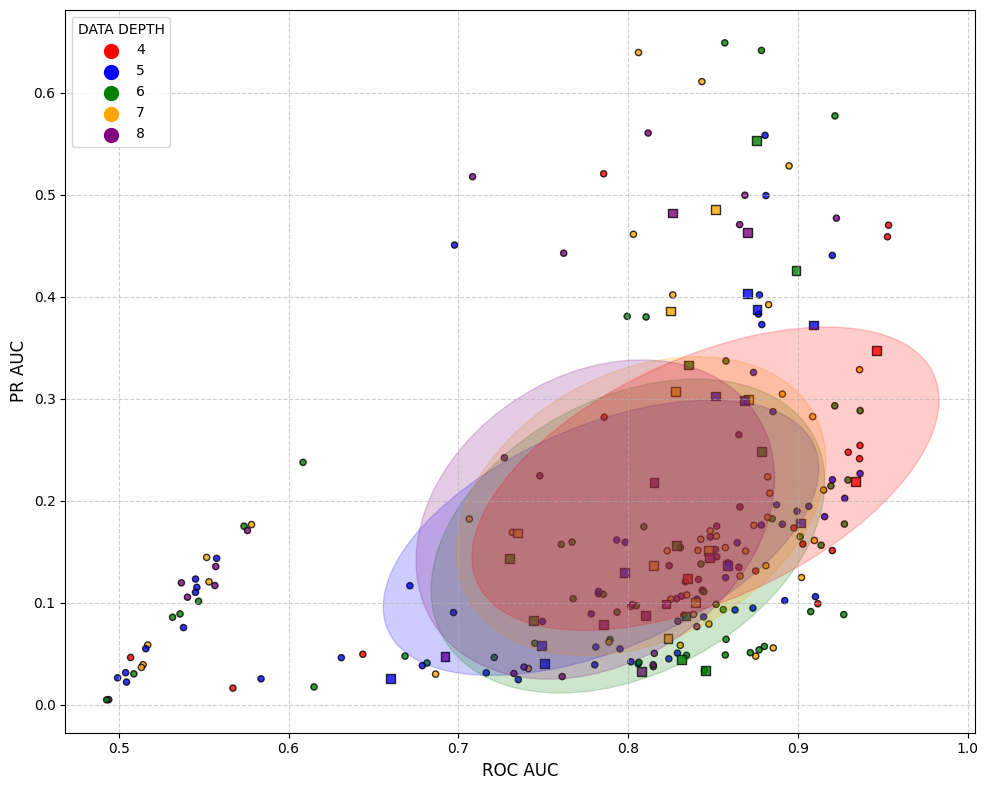

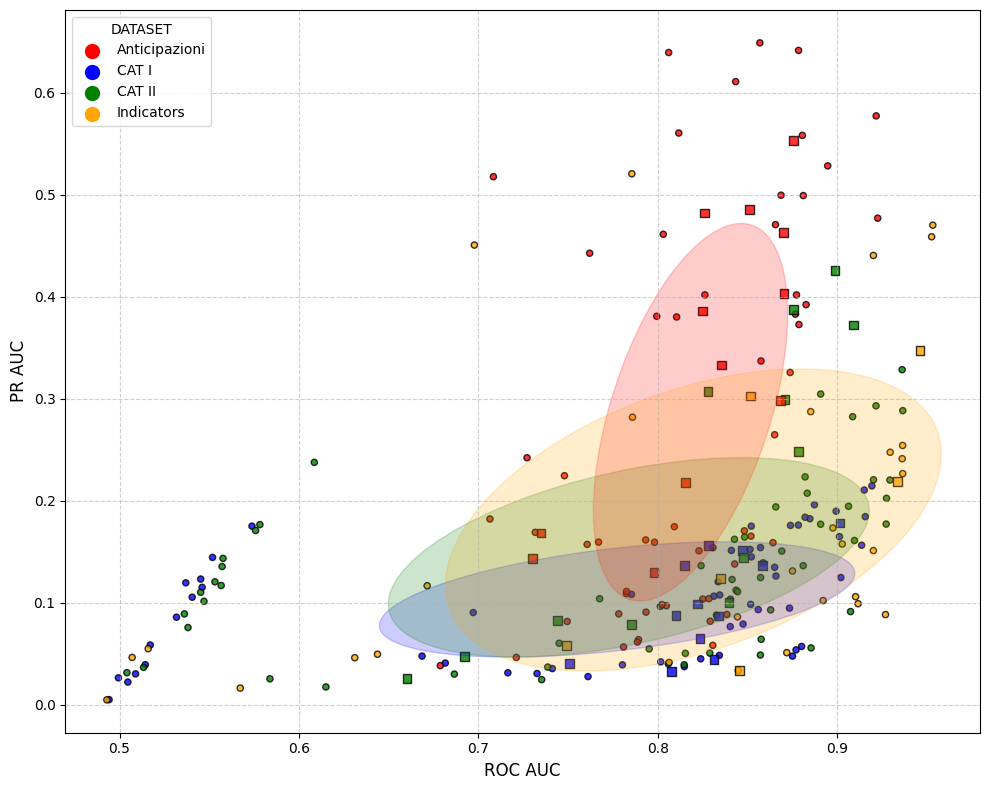

In [30]:
save = 1

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['MODEL', 'TARGET DEPTH', 'DATA DEPTH', 'DATASET']):

    if color_by == "model":
        unique_values = sorted(list(set(model)))
    elif color_by == "pred":
        unique_values = sorted(list(set(pred)))
    elif color_by == "lag":
        unique_values = sorted(list(set(lag)))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))

    if color_by != "model":
        roc_cnn = []
        pr_cnn = []
        color_cnn = []

        roc_other = []
        pr_other = []
        color_other = []

        for i in range(len(model)):
            if model[i] == "CNN":
                roc_cnn.append(roc[i])
                pr_cnn.append(pr[i])
                color_cnn.append(label_colors[i])
            else:
                roc_other.append(roc[i])
                pr_other.append(pr[i])
                color_other.append(label_colors[i])

        # Plot non-CNN points as circles
        plt.scatter(roc_other, pr_other, c=color_other, s=20, edgecolor='k', alpha=0.8)

        # Plot CNN points as squares with correct color
        plt.scatter(roc_cnn, pr_cnn, c=color_cnn, s=40, marker='s', edgecolor='k', alpha=0.8)

    else:
        # If coloring by model, treat all equally
        plt.scatter(roc, pr, c=label_colors, s=20, edgecolor='k', alpha=0.8)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='upper left')

    grouped_points = {}

    for i in range(len(roc)):
        key = None
        if color_by == "model":
            key = model[i]
        elif color_by == "pred":
            key = pred[i]
        elif color_by == "lag":
            key = lag[i]
        elif color_by == "name":
            key = name[i]

        if key not in grouped_points:
            grouped_points[key] = []
        grouped_points[key].append((roc[i], pr[i]))
    
    ax = plt.gca()
    for key, points in grouped_points.items():
        if len(points) >= 2:
            points_array = np.array(points)
            plot_confidence_ellipse(points_array[:, 0], points_array[:, 1], ax, n_std=1.0, edgecolor=cmap[key], facecolor=cmap[key], alpha=0.2)


    plt.xlabel("ROC AUC", fontsize=12) 
    plt.ylabel("PR AUC", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_auc_ellips_squares.png')
    plt.show()

# Normal

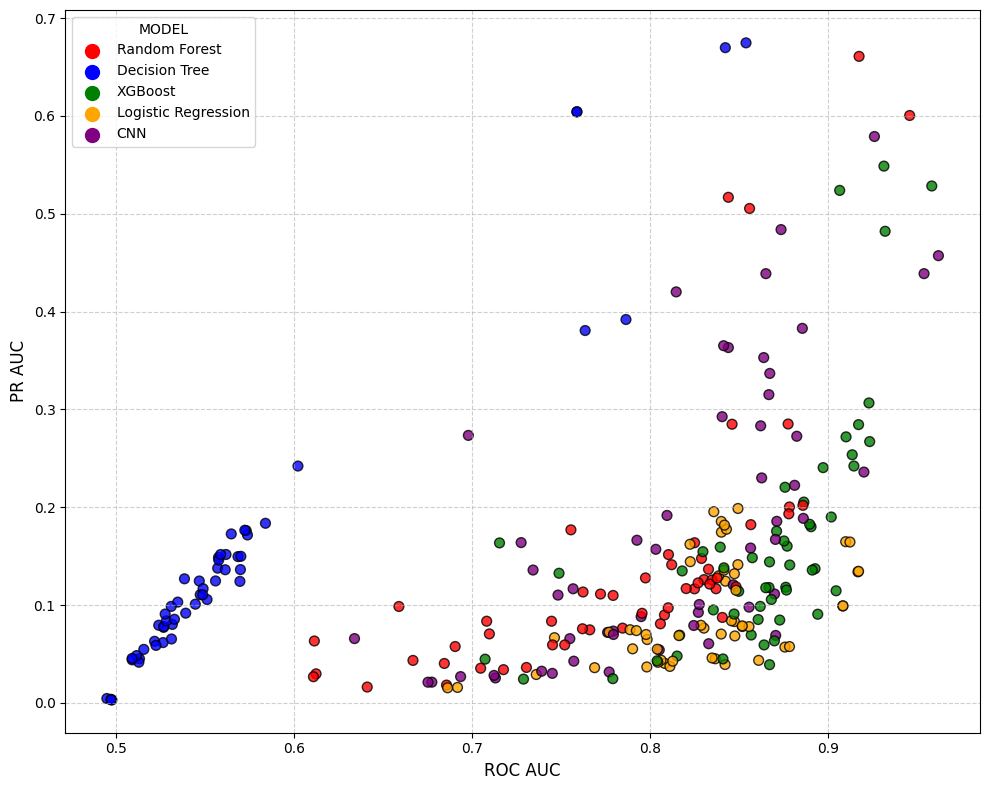

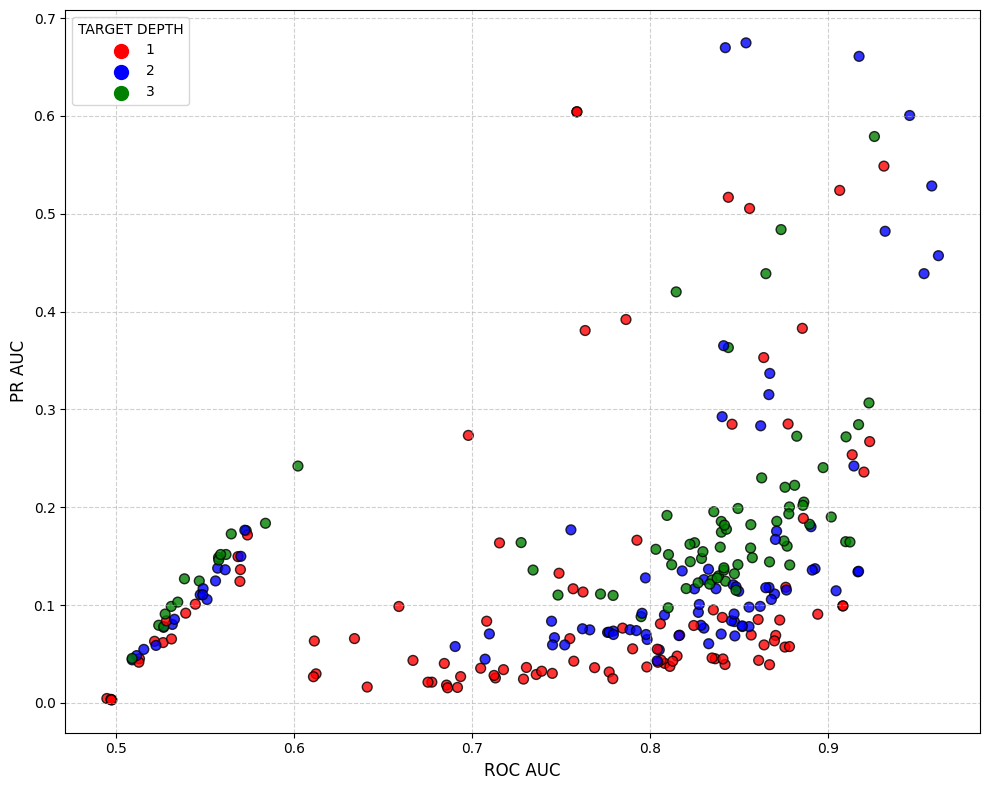

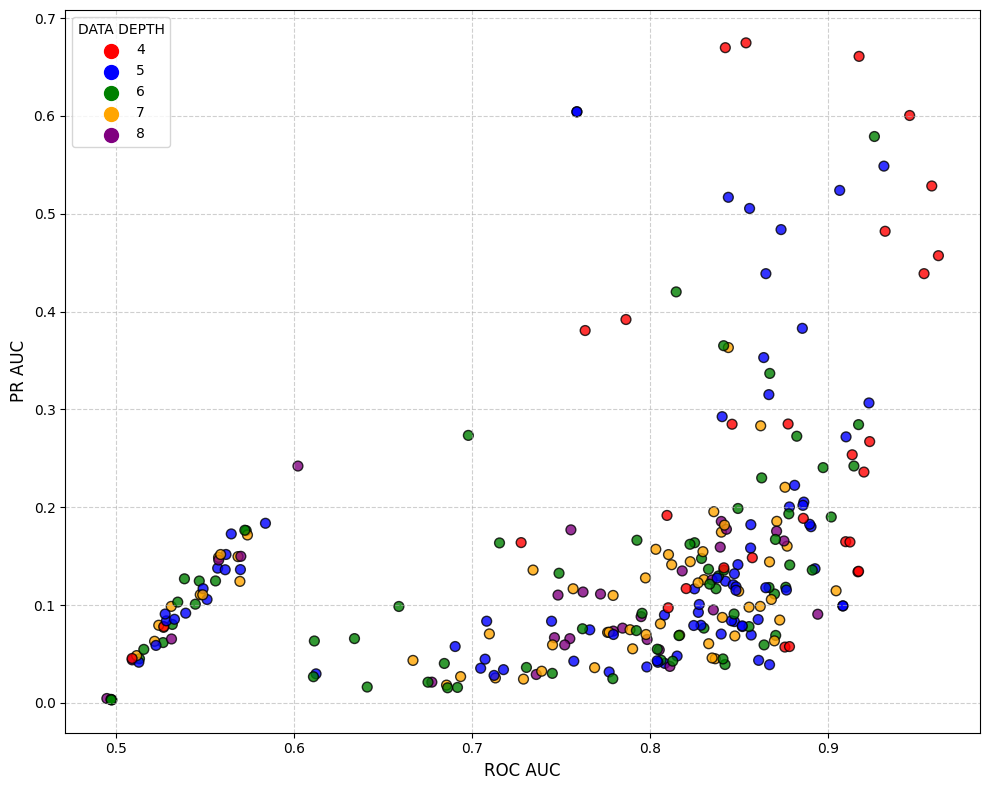

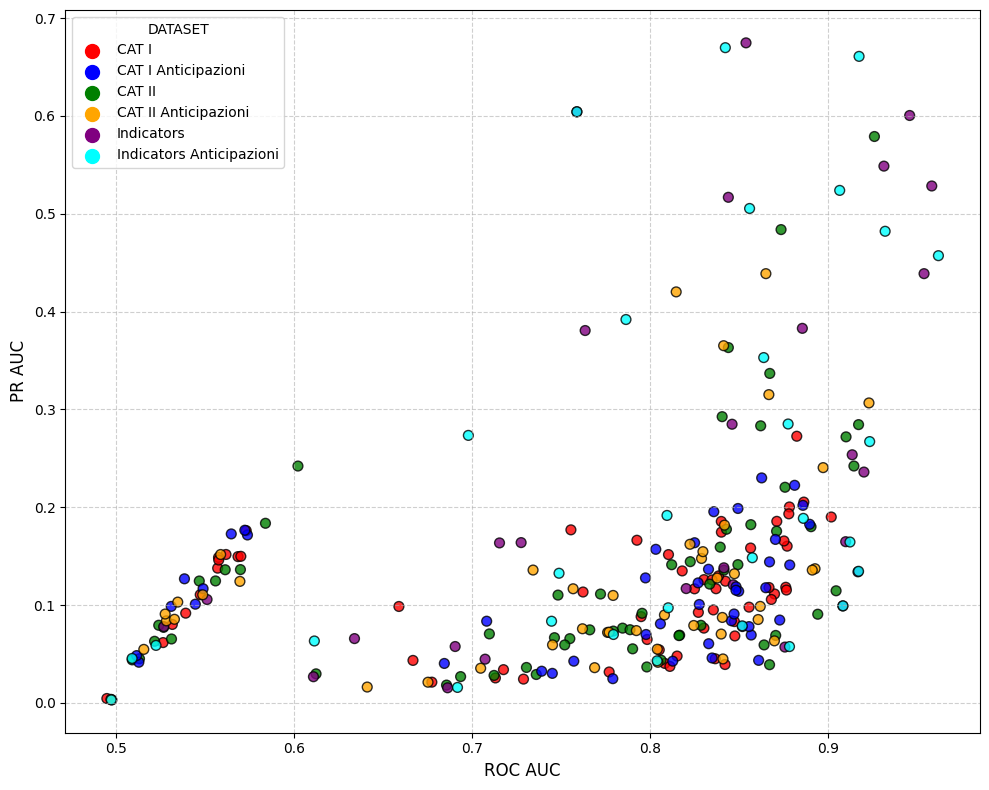

In [25]:
save = 0

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]



for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['MODEL', 'TARGET DEPTH', 'DATA DEPTH', 'DATASET']):

    if color_by == "model":
        unique_values = list(set(model))
    elif color_by == "pred":
        unique_values = list(set(pred))
    elif color_by == "lag":
        unique_values = list(set(lag))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(roc, pr, c=label_colors, s=50, edgecolor='k', alpha=0.8)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='best')


    plt.xlabel("ROC AUC", fontsize=12) 
    plt.ylabel("PR AUC", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_auc.png')
    plt.show()

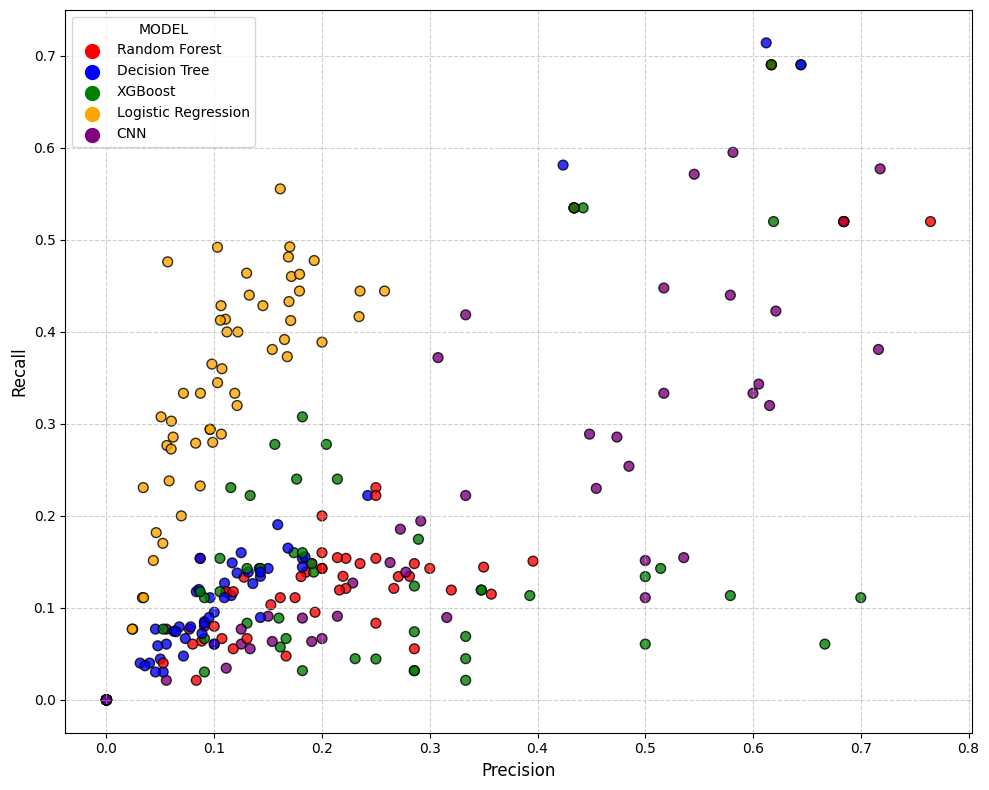

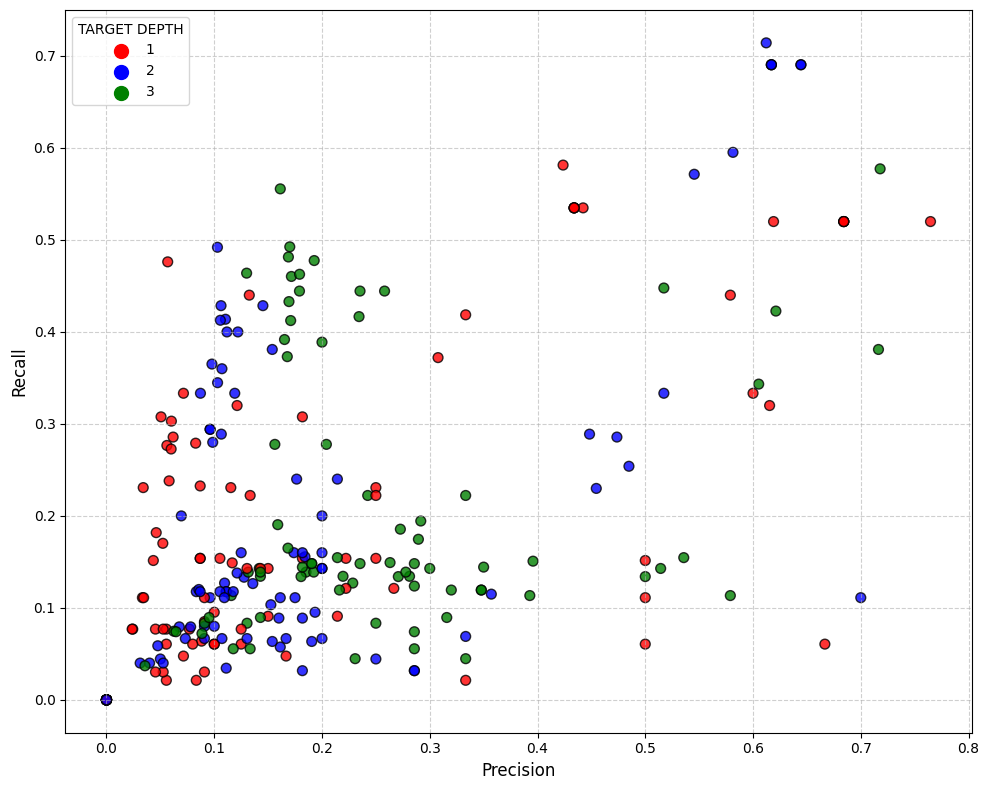

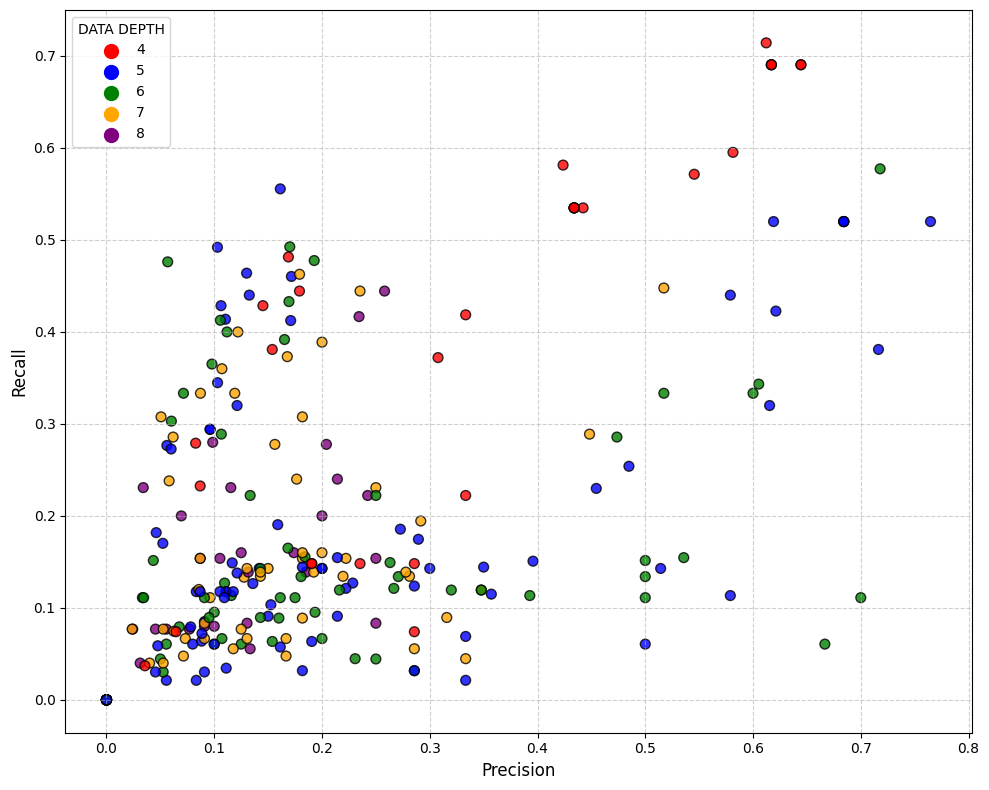

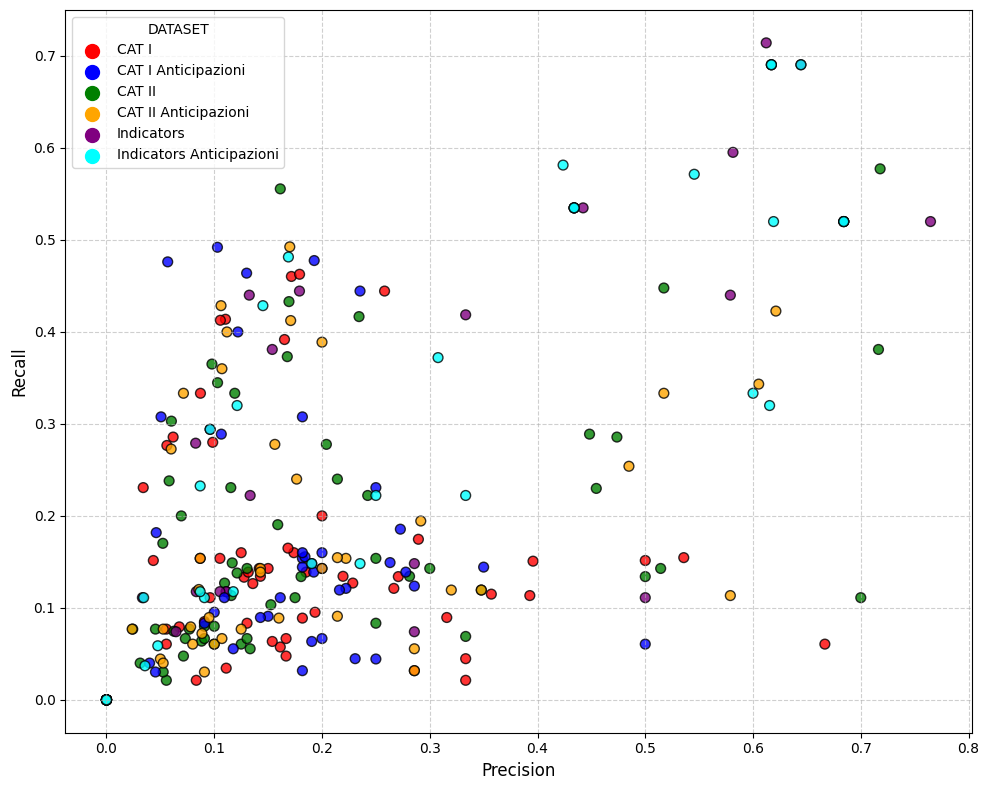

In [21]:
save = 0

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['MODEL', 'TARGET DEPTH', 'DATA DEPTH', 'DATASET']):

    if color_by == "model":
        unique_values = list(set(model))
    elif color_by == "pred":
        unique_values = list(set(pred))
    elif color_by == "lag":
        unique_values = list(set(lag))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(precision, recall, c=label_colors, s=50, edgecolor='k', alpha=0.8)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='upper left')

    plt.xlabel("Precision", fontsize=12) 
    plt.ylabel("Recall", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_precision_recall.png')
    plt.show()

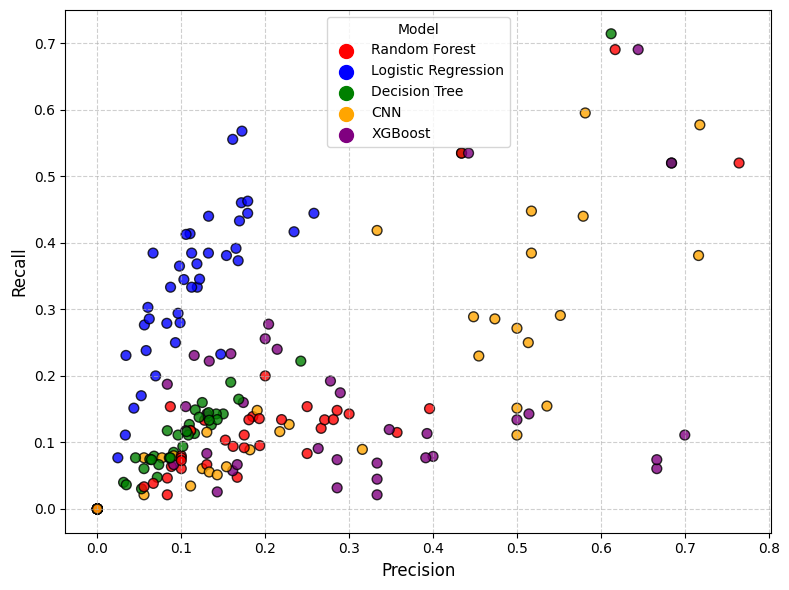

In [6]:
save = 0

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]

color_by = "model"

if color_by == "model":
    unique_values = list(set(model))
elif color_by == "pred":
    unique_values = list(set(pred))
elif color_by == "lag":
    unique_values = list(set(lag))
elif color_by == "name":
    unique_values = list(set(name))
else:
    raise ValueError("Invalid color_by choice")

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

if color_by == "model":
    label_colors = [cmap[m] for m in model]
elif color_by == "pred":
    label_colors = [cmap[p] for p in pred]
elif color_by == "lag":
    label_colors = [cmap[l] for l in lag]
elif color_by == "name":
    label_colors = [cmap[a] for a in name]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(precision, recall, c=label_colors, s=50, edgecolor='k', alpha=0.8)

for value, color in cmap.items():
    plt.scatter([], [], c=color, label=value, s=100)
plt.legend(title=f"{color_by.capitalize()}", loc='best')


plt.xlabel("Precision", fontsize=12) 
plt.ylabel("Recall", fontsize=12)


plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
if save:
    plt.savefig('model_precision_recall.png')
plt.show()

# KDE

In [21]:
from scipy.stats import gaussian_kde
def get_level_for_mass(Z, mass=0.95):
    sorted_Z = np.sort(Z.ravel())[::-1]
    cumsum = np.cumsum(sorted_Z)
    cumsum /= cumsum[-1]  # Normalize to 1
    level = sorted_Z[np.searchsorted(cumsum, mass)]
    return level

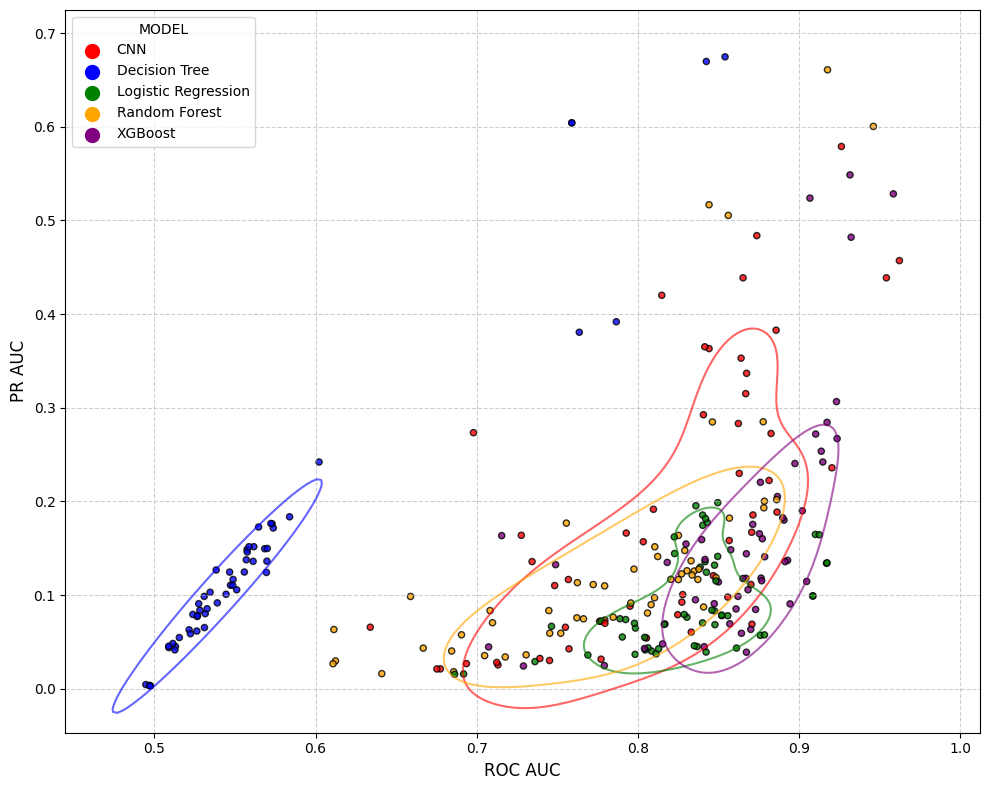

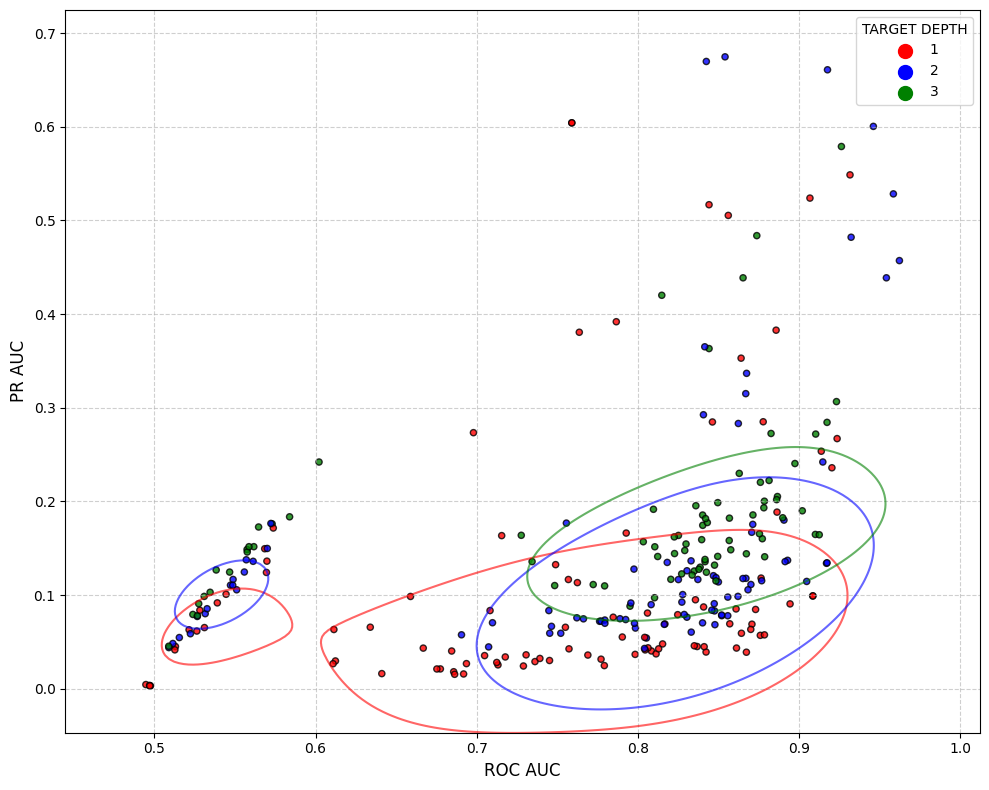

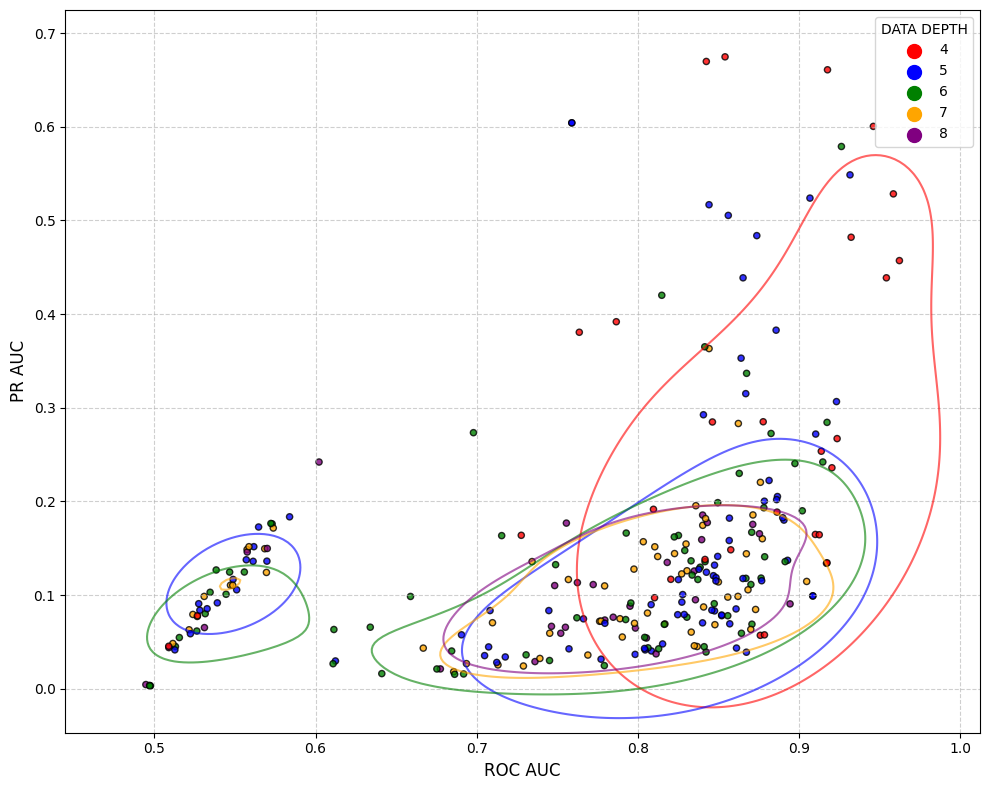

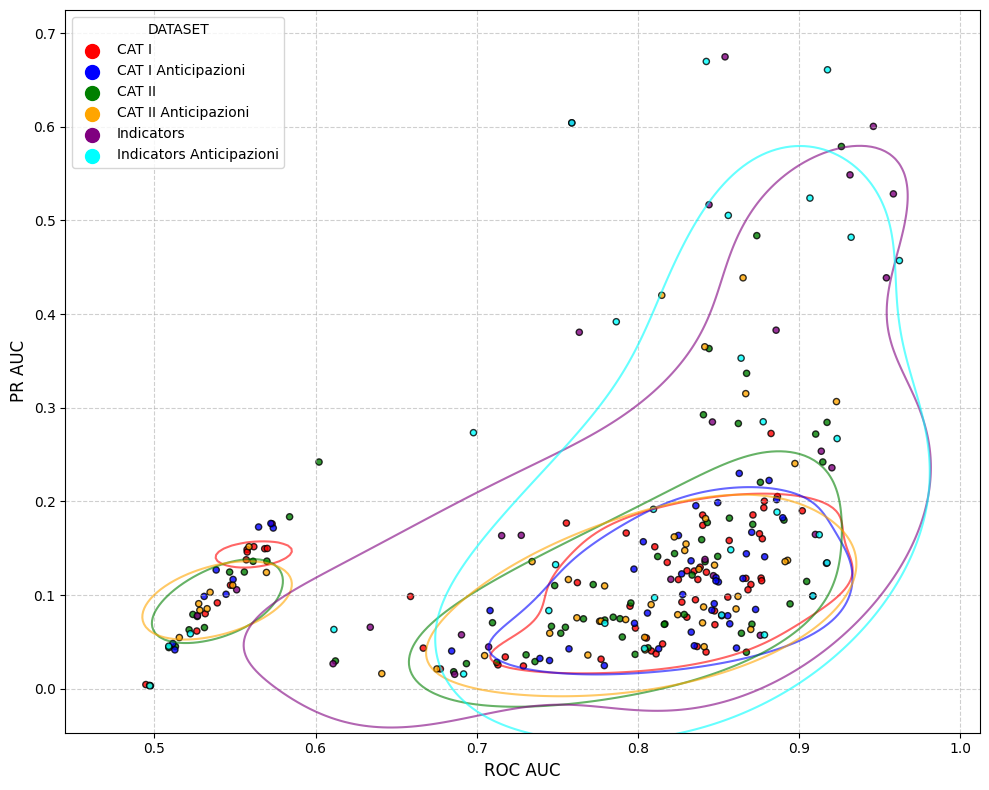

In [50]:
save = 1

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]



for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['MODEL', 'TARGET DEPTH', 'DATA DEPTH', 'DATASET']):

    if color_by == "model":
        unique_values = sorted(list(set(model)))
    elif color_by == "pred":
        unique_values = sorted(list(set(pred)))
    elif color_by == "lag":
        unique_values = sorted(list(set(lag)))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(roc, pr, c=label_colors, s=20, edgecolor='k', alpha=0.8)
    plt.xlim(min(roc)-0.05, max(roc)+0.05)
    plt.ylim(min(pr)-0.05, max(pr)+0.05)

    x_grid = np.linspace(min(roc)-0.5, max(roc)+0.5, 500)
    y_grid = np.linspace(min(pr)-0.5, max(pr)+0.5, 500)
    X, Y = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    for group_value in unique_values:
        if color_by == "model":
            indices = [i for i, m in enumerate(model) if m == group_value]
        elif color_by == "pred":
            indices = [i for i, p in enumerate(pred) if p == group_value]
        elif color_by == "lag":
            indices = [i for i, l in enumerate(lag) if l == group_value]
        elif color_by == "name":
            indices = [i for i, n in enumerate(name) if n == group_value]

        group_roc = [roc[i] for i in indices]
        group_pr = [pr[i] for i in indices]

        if len(group_roc) > 2: 
            values = np.vstack([group_roc, group_pr])
            kernel = gaussian_kde(values)
            Z = np.reshape(kernel(positions).T, X.shape)
            # Z[Z < Z.max() * 0.05] = 0
            level = get_level_for_mass(Z, mass=0.5)
            plt.contour(X, Y, Z, levels=[level], colors=[cmap[group_value]], alpha=0.6)
            # plt.contour(X, Y, Z,levels = 1, colors=[cmap[group_value]], alpha=0.6)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='best')


    plt.xlabel("ROC AUC", fontsize=12) 
    plt.ylabel("PR AUC", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_auc_kde.png')
    plt.show()

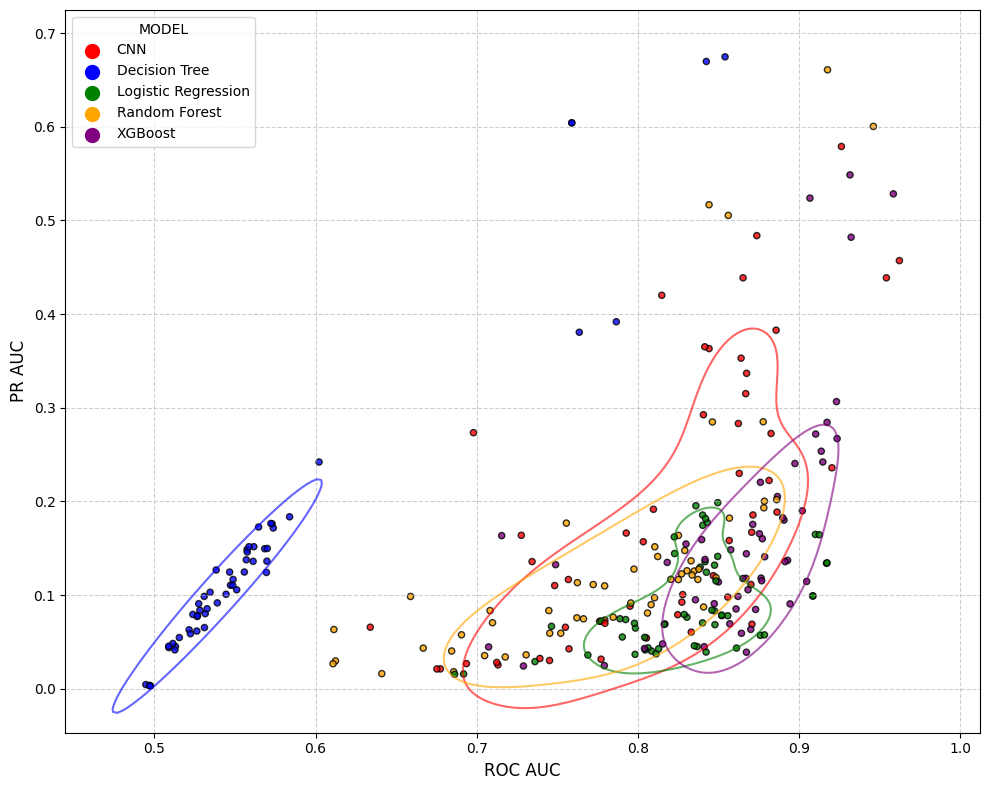

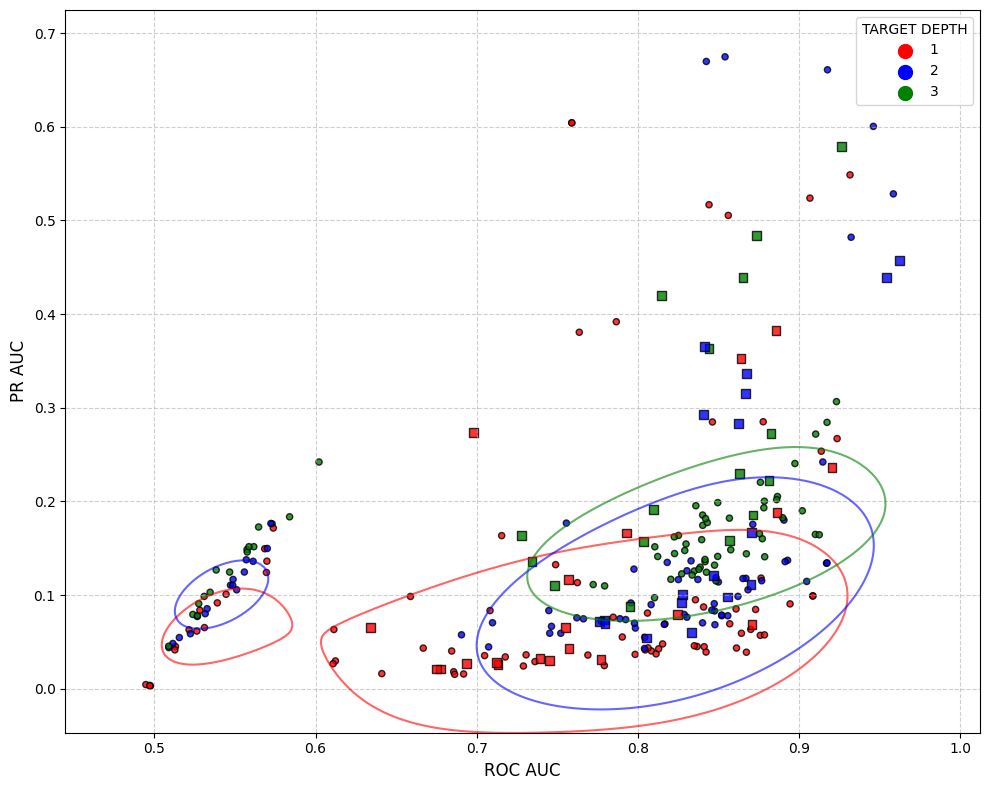

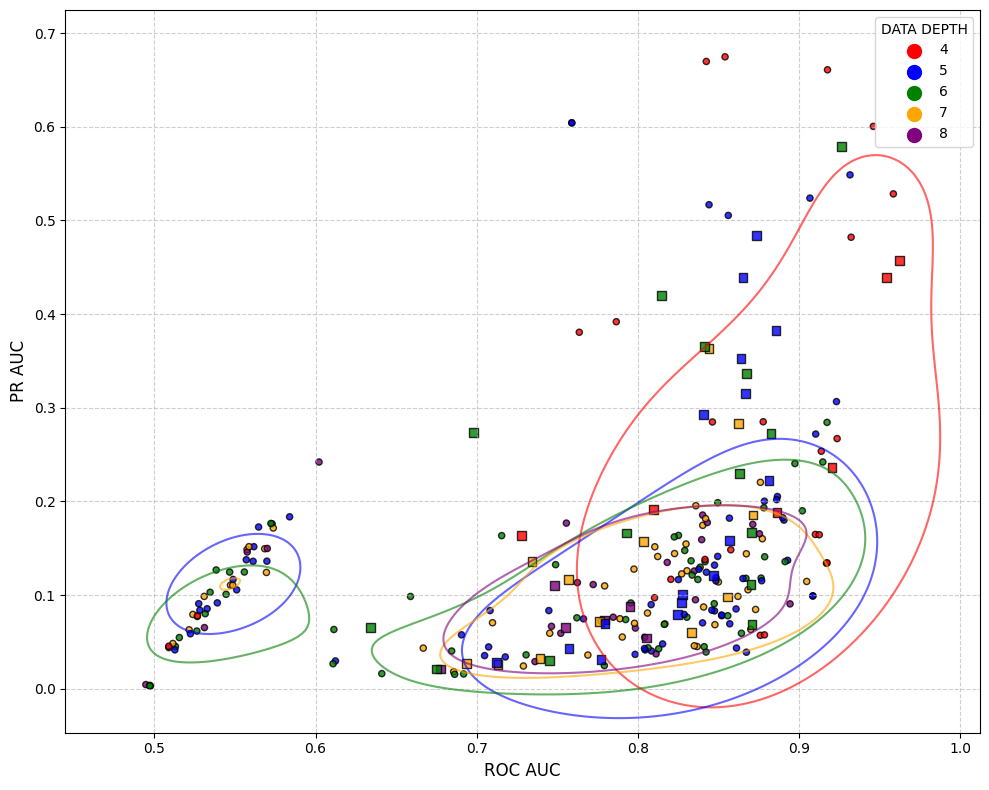

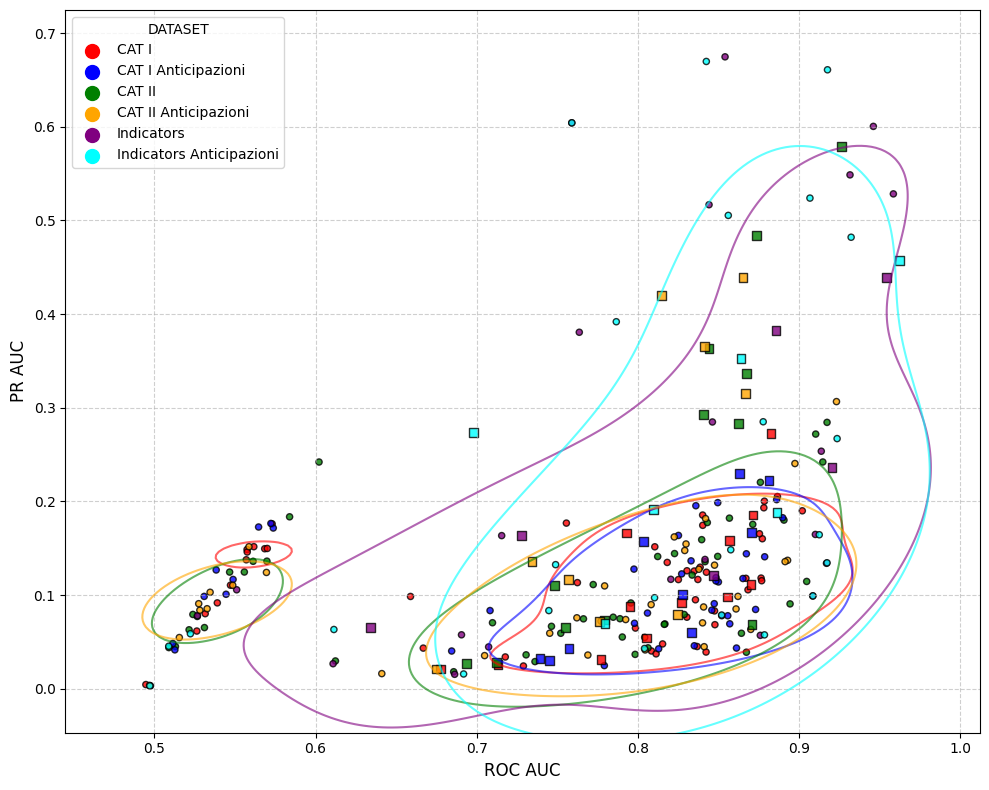

In [52]:
save = 1

name = [elem[0] for elem in labels]
pred = [elem[2] for elem in labels]
lag = [elem[1] for elem in labels]
model = [elem[3] for elem in labels]



for color_by, title in zip(['model', 'pred', 'lag', 'name'], ['MODEL', 'TARGET DEPTH', 'DATA DEPTH', 'DATASET']):

    if color_by == "model":
        unique_values = sorted(list(set(model)))
    elif color_by == "pred":
        unique_values = sorted(list(set(pred)))
    elif color_by == "lag":
        unique_values = sorted(list(set(lag)))
    elif color_by == "name":
        unique_values = sorted(list(set(name)))
    else:
        raise ValueError("Invalid color_by choice")

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']
    cmap = {value: colors[i % len(colors)] for i, value in enumerate(unique_values)}

    if color_by == "model":
        label_colors = [cmap[m] for m in model]
    elif color_by == "pred":
        label_colors = [cmap[p] for p in pred]
    elif color_by == "lag":
        label_colors = [cmap[l] for l in lag]
    elif color_by == "name":
        label_colors = [cmap[a] for a in name]

    plt.figure(figsize=(10, 8))
    if color_by != "model":
        roc_cnn = []
        pr_cnn = []
        color_cnn = []

        roc_other = []
        pr_other = []
        color_other = []

        for i in range(len(model)):
            if model[i] == "CNN":
                roc_cnn.append(roc[i])
                pr_cnn.append(pr[i])
                color_cnn.append(label_colors[i])
            else:
                roc_other.append(roc[i])
                pr_other.append(pr[i])
                color_other.append(label_colors[i])

        # Plot non-CNN points as circles
        plt.scatter(roc_other, pr_other, c=color_other, s=20, edgecolor='k', alpha=0.8)

        # Plot CNN points as squares with correct color
        plt.scatter(roc_cnn, pr_cnn, c=color_cnn, s=40, marker='s', edgecolor='k', alpha=0.8)

    else:
        # If coloring by model, treat all equally
        plt.scatter(roc, pr, c=label_colors, s=20, edgecolor='k', alpha=0.8)
    plt.xlim(min(roc)-0.05, max(roc)+0.05)
    plt.ylim(min(pr)-0.05, max(pr)+0.05)

    x_grid = np.linspace(min(roc)-0.5, max(roc)+0.5, 500)
    y_grid = np.linspace(min(pr)-0.5, max(pr)+0.5, 500)
    X, Y = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    for group_value in unique_values:
        if color_by == "model":
            indices = [i for i, m in enumerate(model) if m == group_value]
        elif color_by == "pred":
            indices = [i for i, p in enumerate(pred) if p == group_value]
        elif color_by == "lag":
            indices = [i for i, l in enumerate(lag) if l == group_value]
        elif color_by == "name":
            indices = [i for i, n in enumerate(name) if n == group_value]

        group_roc = [roc[i] for i in indices]
        group_pr = [pr[i] for i in indices]

        if len(group_roc) > 2: 
            values = np.vstack([group_roc, group_pr])
            kernel = gaussian_kde(values)
            Z = np.reshape(kernel(positions).T, X.shape)
            # Z[Z < Z.max() * 0.05] = 0
            level = get_level_for_mass(Z, mass=0.5)
            plt.contour(X, Y, Z, levels=[level], colors=[cmap[group_value]], alpha=0.6)
            # plt.contour(X, Y, Z,levels = 1, colors=[cmap[group_value]], alpha=0.6)

    for value, color in cmap.items():
        plt.scatter([], [], c=color, label=value, s=100)
    plt.legend(title=f"{title}", loc='best')


    plt.xlabel("ROC AUC", fontsize=12) 
    plt.ylabel("PR AUC", fontsize=12)


    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}_auc_kde_square.png')
    plt.show()